<a href="https://colab.research.google.com/github/gerald-hlabiso/business-analytics-portfolio/blob/main/projects/bert-sms-spam-detection/bert-sms-spam-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT SMS Spam Detection

## Project Overview

SMS spam exposes users and organizations to phishing, fraud, unwanted advertising, and malicious links. This project evaluates whether a fine-tuned BERT transformer can identify spam messages more effectively than a traditional machine-learning baseline.

### Business Question

**Can a fine-tuned BERT model improve SMS spam detection while maintaining an acceptable balance between missed spam messages and incorrectly blocked legitimate messages?**

### Project Approach

This notebook:

- Loads and validates the UCI SMS Spam Collection dataset
- Examines class imbalance between legitimate and spam messages
- Creates stratified training, validation, and testing datasets
- Builds a TF-IDF and Logistic Regression baseline
- Fine-tunes `google-bert/bert-base-uncased`
- Applies class-weighted loss to address spam underrepresentation
- Evaluates accuracy, precision, recall, F1 score, and ROC-AUC
- Compares the baseline with BERT
- Tests the final model using realistic SMS examples
- Interprets the results from a business and risk perspective

### Dataset and Model

- **Dataset:** `ucirvine/sms_spam`
- **Observations:** 5,574 SMS messages
- **Target classes:** Ham and Spam
- **Transformer:** `google-bert/bert-base-uncased`
- **Baseline:** TF-IDF with Logistic Regression
- **Task:** Binary text classification

> **Recommended environment:** Google Colab with GPU enabled through  
> **Runtime → Change runtime type → T4 GPU**

In [2]:
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib pandas

## 2. Import libraries

In [3]:
import os
import inspect
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict, ClassLabel, Features, Value
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
def load_sms_spam_dataset():
    try:
        raw_dataset = load_dataset("ucirvine/sms_spam")
        dataset = raw_dataset["train"]
        print("Loaded dataset from Hugging Face: ucirvine/sms_spam")
        return dataset
    except Exception as e:
        print("Hugging Face load failed. Trying UCI fallback...")
        print("Original error:", repr(e))

        import io
        import zipfile
        import requests

        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
        response = requests.get(url)
        response.raise_for_status()

        z = zipfile.ZipFile(io.BytesIO(response.content))
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", names=["label_text", "sms"], header=None)

        df["label"] = df["label_text"].map({"ham": 0, "spam": 1})
        df = df[["sms", "label"]].dropna()

        features = Features({
            "sms": Value("string"),
            "label": ClassLabel(names=["ham", "spam"])
        })

        dataset = Dataset.from_pandas(df, features=features, preserve_index=False)
        print("Loaded dataset from UCI fallback.")
        return dataset

dataset = load_sms_spam_dataset()

print(dataset)
print(dataset.column_names)
print(dataset.features)
print(dataset[0])


README.md:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  359kB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

Loaded dataset from Hugging Face: ucirvine/sms_spam
Dataset({
    features: ['sms', 'label'],
    num_rows: 5574
})
['sms', 'label']
{'sms': Value('string'), 'label': ClassLabel(names=['ham', 'spam'])}
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}


In [5]:
# Identify the text column automatically.
text_col = None

for col in dataset.column_names:
    try:
        if dataset.features[col].dtype == "string":
            text_col = col
            break
    except Exception:
        pass

label_col = "label"

print("Text column:", text_col)
print("Label column:", label_col)

if text_col is None:
    raise ValueError("No text column was found. Please inspect dataset.column_names.")


Text column: sms
Label column: label


In [6]:
# Make sure labels are a ClassLabel type.
if not isinstance(dataset.features[label_col], ClassLabel):
    dataset = dataset.class_encode_column(label_col)

label_names = dataset.features[label_col].names
num_labels = len(label_names)

print("Label names:", label_names)
print("Number of labels:", num_labels)


Label names: ['ham', 'spam']
Number of labels: 2


In [7]:
train_test = dataset.train_test_split(
    test_size=0.20,
    seed=42,
    stratify_by_column=label_col
)

valid_test = train_test["test"].train_test_split(
    test_size=0.50,
    seed=42,
    stratify_by_column=label_col
)

dataset_split = DatasetDict({
    "train": train_test["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"]
})

dataset_split


DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 4459
    })
    validation: Dataset({
        features: ['sms', 'label'],
        num_rows: 557
    })
    test: Dataset({
        features: ['sms', 'label'],
        num_rows: 558
    })
})

In [8]:
train_df = dataset_split["train"].to_pandas()
val_df = dataset_split["validation"].to_pandas()
test_df = dataset_split["test"].to_pandas()

print("Training class counts:")
print(train_df[label_col].value_counts().sort_index())

print("\nValidation class counts:")
print(val_df[label_col].value_counts().sort_index())

print("\nTest class counts:")
print(test_df[label_col].value_counts().sort_index())

class_count_table = pd.DataFrame({
    "class_id": range(num_labels),
    "class_name": label_names,
    "train_count": [int((train_df[label_col] == i).sum()) for i in range(num_labels)],
    "validation_count": [int((val_df[label_col] == i).sum()) for i in range(num_labels)],
    "test_count": [int((test_df[label_col] == i).sum()) for i in range(num_labels)]
})

class_count_table


Training class counts:
label
0    3861
1     598
Name: count, dtype: int64

Validation class counts:
label
0    483
1     74
Name: count, dtype: int64

Test class counts:
label
0    483
1     75
Name: count, dtype: int64


,class_id,class_name,train_count,validation_count,test_count
0,0,ham,3861,483,483
1,1,spam,598,74,75


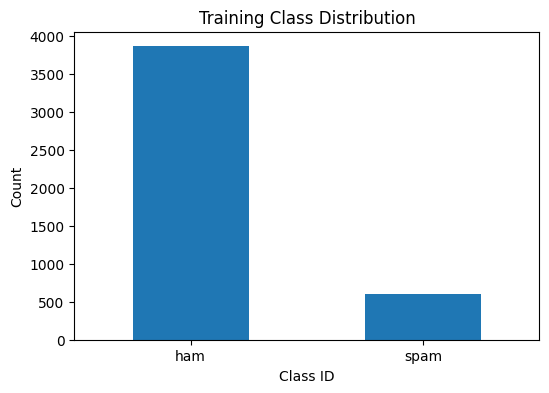

In [9]:
plt.figure(figsize=(6, 4))
train_df[label_col].value_counts().sort_index().plot(kind="bar")
plt.title("Training Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.xticks(ticks=range(num_labels), labels=label_names, rotation=0)
plt.show()


In [10]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

baseline.fit(train_df[text_col], train_df[label_col])

baseline_preds = baseline.predict(test_df[text_col])

if hasattr(baseline.named_steps["clf"], "predict_proba"):
    baseline_probs = baseline.predict_proba(test_df[text_col])[:, 1]
else:
    baseline_probs = None

print("Baseline Classification Report")
print(classification_report(
    test_df[label_col],
    baseline_preds,
    target_names=label_names,
    zero_division=0
))

baseline_acc = accuracy_score(test_df[label_col], baseline_preds)
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    test_df[label_col],
    baseline_preds,
    average="binary",
    zero_division=0
)

try:
    baseline_auc = roc_auc_score(test_df[label_col], baseline_probs) if baseline_probs is not None else np.nan
except Exception:
    baseline_auc = np.nan

baseline_metrics = {
    "model": "TF-IDF + Logistic Regression",
    "accuracy": baseline_acc,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "auc": baseline_auc
}

baseline_metrics


Baseline Classification Report
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.96      0.92      0.94        75

    accuracy                           0.98       558
   macro avg       0.97      0.96      0.96       558
weighted avg       0.98      0.98      0.98       558



{'model': 'TF-IDF + Logistic Regression',
 'accuracy': 0.9838709677419355,
 'precision': 0.9583333333333334,
 'recall': 0.92,
 'f1': 0.9387755102040817,
 'auc': np.float64(0.9758730158730159)}

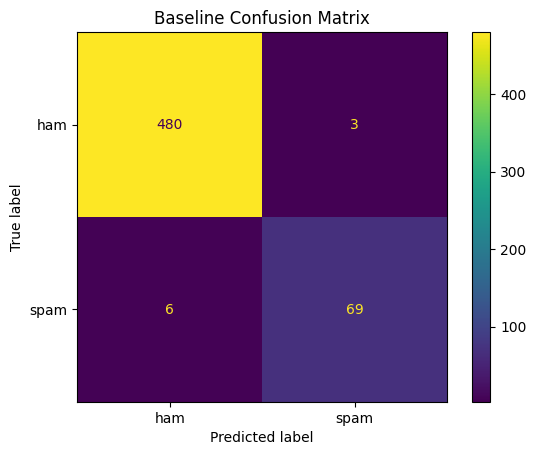

In [11]:
baseline_cm = confusion_matrix(test_df[label_col], baseline_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=label_names
)

disp.plot(values_format="d")
plt.title("Baseline Confusion Matrix")
plt.show()


In [12]:
model_name = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print("Loaded:", model_name)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: google-bert/bert-base-uncased


In [13]:
max_length = 128

def tokenize_function(batch):
    return tokenizer(
        batch[text_col],
        truncation=True,
        padding=False,
        max_length=max_length
    )

tokenized_dataset = dataset_split.map(tokenize_function, batched=True)

# Rename label column to labels because Trainer expects the label column to be named labels.
tokenized_dataset = tokenized_dataset.rename_column(label_col, "labels")

# Keep only the columns needed by BERT.
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset


Map:   0%|          | 0/4459 [00:00<?, ? examples/s]

Map:   0%|          | 0/557 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sms', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4459
    })
    validation: Dataset({
        features: ['sms', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 557
    })
    test: Dataset({
        features: ['sms', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 558
    })
})

In [14]:
def stable_softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)
    probs = stable_softmax(logits)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except Exception:
        auc = np.nan

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }


In [15]:
train_labels = np.array(dataset_split["train"][label_col])

class_counts = np.bincount(train_labels, minlength=num_labels)
class_weights = len(train_labels) / (num_labels * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class counts:", class_counts)
print("Class weights:", class_weights)


Class counts: [3861  598]
Class weights: tensor([0.5774, 3.7283])


In [16]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}

        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss


In [21]:
# Create training arguments that remain compatible with different
# versions of the Hugging Face Transformers library.

training_args_signature = inspect.signature(
    TrainingArguments.__init__
).parameters

training_args_dict = {
    "output_dir": "./bert_sms_spam_results",
    "save_strategy": "epoch",
    "logging_strategy": "steps",
    "logging_steps": 25,
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "num_train_epochs": 3,
    "weight_decay": 0.01,
    "warmup_steps": 84,
    "lr_scheduler_type": "linear",
    "max_grad_norm": 1.0,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "report_to": []
}

# Transformers versions use either eval_strategy or evaluation_strategy.
if "eval_strategy" in training_args_signature:
    training_args_dict["eval_strategy"] = "epoch"
elif "evaluation_strategy" in training_args_signature:
    training_args_dict["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_dict)

print("Training arguments created successfully.")
print(training_args)

Training arguments created successfully.
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
e

In [22]:
trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": tokenized_dataset["train"],
    "eval_dataset": tokenized_dataset["validation"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics
}

# Some Transformers versions accept processing_class; some do not.
# This is optional, but useful when supported.
trainer_signature = inspect.signature(Trainer.__init__).parameters

if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

train_result = trainer.train()

print("Training complete.")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.051514,0.050381,0.994614,0.986301,0.972973,0.979592,0.999944
2,0.055370,0.026932,0.991023,0.936709,1.000000,0.967320,0.999776
3,0.000677,0.034338,0.994614,0.973333,0.986486,0.979866,0.999888


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training complete.


In [23]:
val_results = trainer.evaluate(eval_dataset=tokenized_dataset["validation"])
val_results


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.000677,0.034338,3,0.994614,0.973333,0.986486,0.979866,0.999888


{'eval_loss': 0.034338440746068954,
 'eval_accuracy': 0.9946140035906643,
 'eval_precision': 0.9733333333333334,
 'eval_recall': 0.9864864864864865,
 'eval_f1': 0.9798657718120806,
 'eval_auc': 0.9998880868446085}

In [24]:
test_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

test_probs = stable_softmax(test_logits)

print("BERT Test Classification Report")
print(classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0
))

bert_acc = accuracy_score(test_labels, test_preds)
bert_precision, bert_recall, bert_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average="binary",
    zero_division=0
)

try:
    bert_auc = roc_auc_score(test_labels, test_probs[:, 1])
except Exception:
    bert_auc = np.nan

bert_metrics = {
    "model": "Fine-tuned BERT",
    "accuracy": bert_acc,
    "precision": bert_precision,
    "recall": bert_recall,
    "f1": bert_f1,
    "auc": bert_auc
}

bert_metrics


BERT Test Classification Report
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.93      0.93      0.93        75

    accuracy                           0.98       558
   macro avg       0.96      0.96      0.96       558
weighted avg       0.98      0.98      0.98       558



{'model': 'Fine-tuned BERT',
 'accuracy': 0.982078853046595,
 'precision': 0.9333333333333333,
 'recall': 0.9333333333333333,
 'f1': 0.9333333333333333,
 'auc': np.float64(0.9982056590752243)}

## 18. BERT confusion matrix

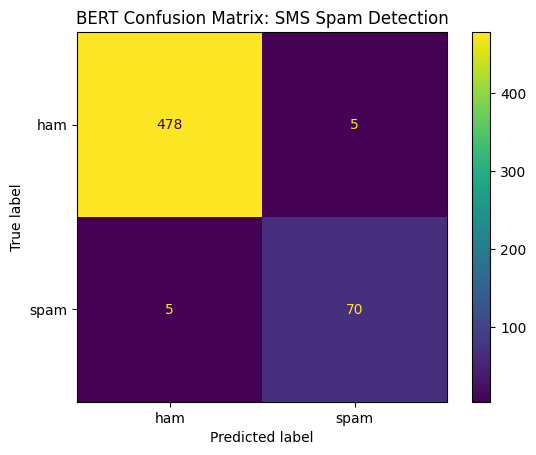

In [25]:
bert_cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=bert_cm,
    display_labels=label_names
)

disp.plot(values_format="d")
plt.title("BERT Confusion Matrix: SMS Spam Detection")
plt.show()


## 19. Training loss, validation loss, and learning rate schedule

In [26]:
logs = pd.DataFrame(trainer.state.log_history)
logs.head()


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.667975,5.935217,0.000006,0.089606,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.436469,38.355450,0.000012,0.179211,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.191846,2.421001,0.000018,0.268817,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.141551,0.965103,0.000020,0.358423,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.137503,0.289488,0.000019,0.448029,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


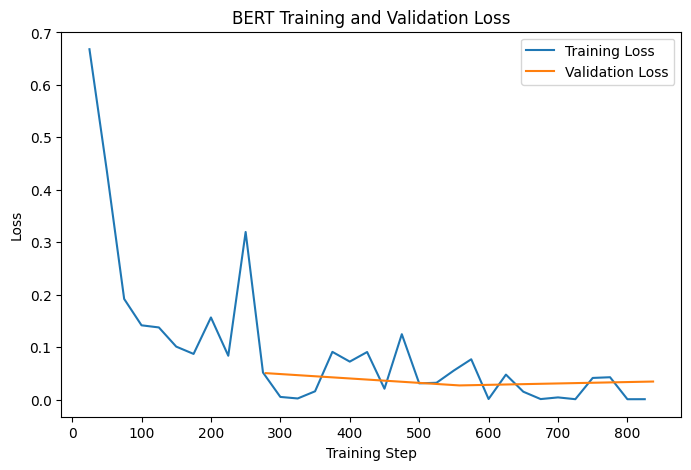

In [27]:
train_logs = logs[logs["loss"].notna()] if "loss" in logs.columns else pd.DataFrame()
eval_logs = logs[logs["eval_loss"].notna()] if "eval_loss" in logs.columns else pd.DataFrame()

plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")

plt.title("BERT Training and Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.show()


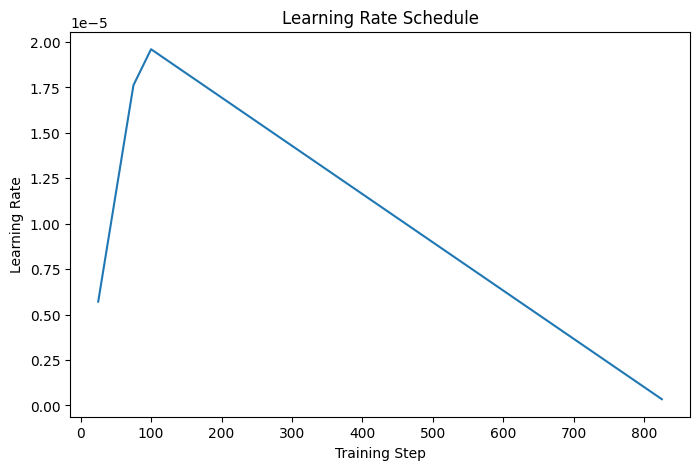

In [28]:
if "learning_rate" in train_logs.columns and len(train_logs) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(train_logs["step"], train_logs["learning_rate"])
    plt.title("Learning Rate Schedule")
    plt.xlabel("Training Step")
    plt.ylabel("Learning Rate")
    plt.show()
else:
    print("Learning rate values were not found in the logs.")


## 20. Compare baseline vs BERT

In [29]:
results_df = pd.DataFrame([baseline_metrics, bert_metrics])

# Round values for clearer reporting.
display_results = results_df.copy()
for col in ["accuracy", "precision", "recall", "f1", "auc"]:
    display_results[col] = display_results[col].astype(float).round(4)

display_results


,model,accuracy,precision,recall,f1,auc
0,TF-IDF + Logistic Regression,0.9839,0.9583,0.9200,0.9388,0.9759
1,Fine-tuned BERT,0.9821,0.9333,0.9333,0.9333,0.9982


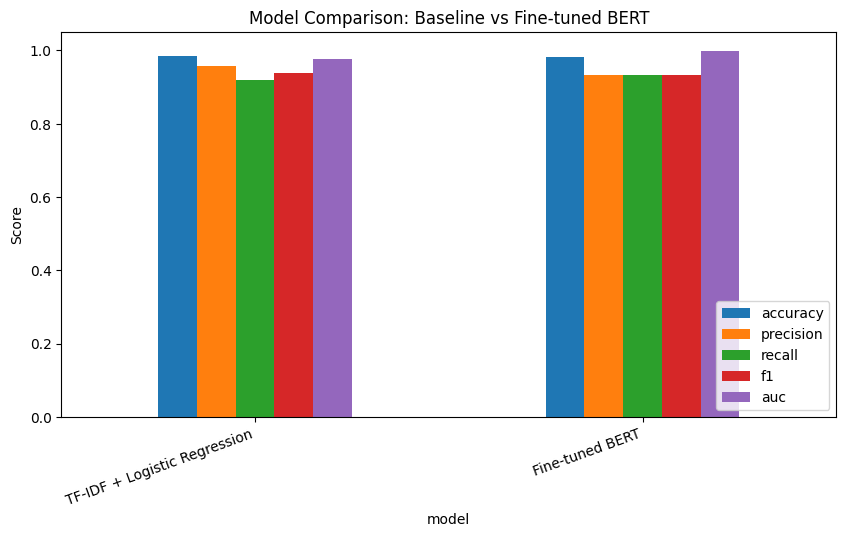

In [30]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1", "auc"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Comparison: Baseline vs Fine-tuned BERT")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.show()


In [31]:
def predict_sms(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    # Move inputs to the same device as the model.
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))

    return {
        "text": text,
        "prediction": label_names[pred_id],
        "confidence": round(float(probs[pred_id]), 4),
        "ham_probability": round(float(probs[0]), 4),
        "spam_probability": round(float(probs[1]), 4)
    }


In [32]:
example_messages = [
    "Congratulations! You have won a free prize. Click here to claim now.",
    "Hey, are we still meeting for class tomorrow?",
    "Urgent! Your account has been locked. Verify your details immediately.",
    "Can you call me when you get home?"
]

for msg in example_messages:
    print(predict_sms(msg))


{'text': 'Congratulations! You have won a free prize. Click here to claim now.', 'prediction': 'spam', 'confidence': 0.9994, 'ham_probability': 0.0006, 'spam_probability': 0.9994}
{'text': 'Hey, are we still meeting for class tomorrow?', 'prediction': 'ham', 'confidence': 0.9994, 'ham_probability': 0.9994, 'spam_probability': 0.0006}
{'text': 'Urgent! Your account has been locked. Verify your details immediately.', 'prediction': 'ham', 'confidence': 0.5775, 'ham_probability': 0.5775, 'spam_probability': 0.4225}
{'text': 'Can you call me when you get home?', 'prediction': 'ham', 'confidence': 0.9995, 'ham_probability': 0.9995, 'spam_probability': 0.0005}


In [33]:
os.makedirs("outputs", exist_ok=True)

results_df.to_csv("outputs/model_comparison_results.csv", index=False)
logs.to_csv("outputs/training_logs.csv", index=False)

trainer.save_model("outputs/fine_tuned_bert_sms_spam")
tokenizer.save_pretrained("outputs/fine_tuned_bert_sms_spam")

print("Saved model, tokenizer, training logs, and model comparison results in the outputs folder.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model, tokenizer, training logs, and model comparison results in the outputs folder.


## Precision–Recall Analysis

Because legitimate messages substantially outnumber spam messages, accuracy alone can hide important model weaknesses. The precision–recall curve evaluates the tradeoff between:

- **Precision:** How many messages flagged as spam are actually spam
- **Recall:** How much of the available spam the model successfully detects

Higher recall reduces missed spam, while higher precision reduces legitimate messages incorrectly blocked as spam.

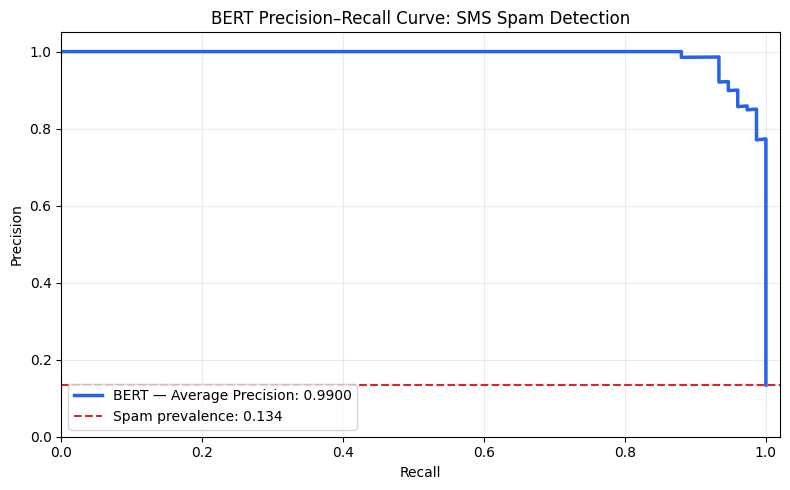

Average Precision: 0.9900


In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score

spam_probs = test_probs[:, 1]

precision_values, recall_values, thresholds = precision_recall_curve(
    test_labels,
    spam_probs
)

average_precision = average_precision_score(
    test_labels,
    spam_probs
)

plt.figure(figsize=(8, 5))
plt.plot(
    recall_values,
    precision_values,
    color="#2563EB",
    linewidth=2.5,
    label=f"BERT — Average Precision: {average_precision:.4f}"
)

plt.axhline(
    y=test_labels.mean(),
    color="#DC2626",
    linestyle="--",
    linewidth=1.5,
    label=f"Spam prevalence: {test_labels.mean():.3f}"
)

plt.title("BERT Precision–Recall Curve: SMS Spam Detection")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.02)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Average Precision: {average_precision:.4f}")

## Decision-Threshold Optimization

A probability score must be converted into a business decision. The standard threshold of 0.50 may not provide the best balance between blocking legitimate messages and allowing spam through.

To avoid tuning the model on the test set, the threshold is selected using the validation dataset. The chosen threshold is then applied once to the held-out test dataset.

In [37]:
# ============================================================
# DECISION-THRESHOLD OPTIMIZATION USING VALIDATION DATA
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Generate validation-set predictions
# ------------------------------------------------------------

validation_output = trainer.predict(
    tokenized_dataset["validation"]
)

validation_logits = validation_output.predictions
validation_labels = validation_output.label_ids

# Handle models that return predictions inside a tuple.
if isinstance(validation_logits, tuple):
    validation_logits = validation_logits[0]

# Convert model logits into spam probabilities.
validation_probabilities = stable_softmax(
    validation_logits
)

validation_spam_probabilities = validation_probabilities[:, 1]

# ------------------------------------------------------------
# 2. Test multiple decision thresholds
# ------------------------------------------------------------

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    validation_predictions = (
        validation_spam_probabilities >= threshold
    ).astype(int)

    threshold_precision = precision_score(
        validation_labels,
        validation_predictions,
        zero_division=0
    )

    threshold_recall = recall_score(
        validation_labels,
        validation_predictions,
        zero_division=0
    )

    threshold_f1 = f1_score(
        validation_labels,
        validation_predictions,
        zero_division=0
    )

    false_positives = int(
        (
            (validation_predictions == 1) &
            (validation_labels == 0)
        ).sum()
    )

    false_negatives = int(
        (
            (validation_predictions == 0) &
            (validation_labels == 1)
        ).sum()
    )

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": threshold_precision,
        "recall": threshold_recall,
        "f1": threshold_f1,
        "false_positives": false_positives,
        "false_negatives": false_negatives
    })

# Convert all threshold results into a table.
threshold_df = pd.DataFrame(threshold_results)

# ------------------------------------------------------------
# 3. Identify every threshold tied for the highest F1 score
# ------------------------------------------------------------

max_validation_f1 = threshold_df["f1"].max()

best_candidates = threshold_df[
    np.isclose(
        threshold_df["f1"],
        max_validation_f1
    )
].copy()

# ------------------------------------------------------------
# 4. Resolve ties using the threshold closest to 0.50
# ------------------------------------------------------------

best_candidates["distance_from_default"] = (
    best_candidates["threshold"] - 0.50
).abs()

best_row = best_candidates.loc[
    best_candidates["distance_from_default"].idxmin()
]

best_threshold = float(
    best_row["threshold"]
)

# ------------------------------------------------------------
# 5. Display the selected threshold and validation results
# ------------------------------------------------------------

print("=" * 65)
print("VALIDATION THRESHOLD OPTIMIZATION")
print("=" * 65)

print(f"Best validation threshold: {best_threshold:.2f}")
print(
    "Validation precision at selected threshold: "
    f"{best_row['precision']:.4f}"
)
print(
    "Validation recall at selected threshold: "
    f"{best_row['recall']:.4f}"
)
print(
    "Validation F1 at selected threshold: "
    f"{best_row['f1']:.4f}"
)
print(
    "False positives at selected threshold: "
    f"{int(best_row['false_positives'])}"
)
print(
    "False negatives at selected threshold: "
    f"{int(best_row['false_negatives'])}"
)

print("\nComplete threshold comparison")
print("-" * 65)

display(
    threshold_df.round({
        "threshold": 2,
        "precision": 4,
        "recall": 4,
        "f1": 4
    })
)

VALIDATION THRESHOLD OPTIMIZATION
Best validation threshold: 0.50
Validation precision at selected threshold: 0.9733
Validation recall at selected threshold: 0.9865
Validation F1 at selected threshold: 0.9799
False positives at selected threshold: 2
False negatives at selected threshold: 1

Complete threshold comparison
-----------------------------------------------------------------


,threshold,precision,recall,f1,false_positives,false_negatives
0,0.10,0.9605,0.9865,0.9733,3,1
1,0.15,0.9733,0.9865,0.9799,2,1
2,0.20,0.9733,0.9865,0.9799,2,1
3,0.25,0.9733,0.9865,0.9799,2,1
4,0.30,0.9733,0.9865,0.9799,2,1
5,0.35,0.9733,0.9865,0.9799,2,1
6,0.40,0.9733,0.9865,0.9799,2,1
7,0.45,0.9733,0.9865,0.9799,2,1
8,0.50,0.9733,0.9865,0.9799,2,1
9,0.55,0.9733,0.9865,0.9799,2,1


In [38]:
# Apply the validation-selected threshold to the held-out test set.
optimized_test_predictions = (
    test_probs[:, 1] >= best_threshold
).astype(int)

# Create message-level results.
test_error_df = test_df[[text_col, label_col]].copy()

test_error_df["actual_label"] = test_error_df[label_col].map({
    0: "ham",
    1: "spam"
})

test_error_df["predicted_label"] = np.where(
    optimized_test_predictions == 1,
    "spam",
    "ham"
)

test_error_df["spam_probability"] = test_probs[:, 1]

# Classify prediction outcomes.
test_error_df["error_type"] = np.select(
    [
        (test_error_df[label_col] == 0) &
        (optimized_test_predictions == 1),

        (test_error_df[label_col] == 1) &
        (optimized_test_predictions == 0)
    ],
    [
        "False Positive",
        "False Negative"
    ],
    default="Correct"
)

# Extract errors.
misclassified_messages = test_error_df[
    test_error_df["error_type"] != "Correct"
].copy()

false_positives = int(
    (misclassified_messages["error_type"] == "False Positive").sum()
)

false_negatives = int(
    (misclassified_messages["error_type"] == "False Negative").sum()
)

# Calculate performance at the selected threshold.
optimized_accuracy = accuracy_score(
    test_labels,
    optimized_test_predictions
)

optimized_precision = precision_score(
    test_labels,
    optimized_test_predictions,
    zero_division=0
)

optimized_recall = recall_score(
    test_labels,
    optimized_test_predictions,
    zero_division=0
)

optimized_f1 = f1_score(
    test_labels,
    optimized_test_predictions,
    zero_division=0
)

print("=" * 65)
print("BERT TEST-SET ERROR ANALYSIS")
print("=" * 65)
print(f"Selected threshold:       {best_threshold:.2f}")
print(f"Total test messages:      {len(test_error_df)}")
print(f"Correct predictions:      {len(test_error_df) - len(misclassified_messages)}")
print(f"Misclassified messages:   {len(misclassified_messages)}")
print(f"False positives:          {false_positives}")
print(f"False negatives:          {false_negatives}")

print("\nTest performance")
print("-" * 65)
print(f"Accuracy:                 {optimized_accuracy:.4f}")
print(f"Spam precision:           {optimized_precision:.4f}")
print(f"Spam recall:              {optimized_recall:.4f}")
print(f"Spam F1 score:            {optimized_f1:.4f}")

display(
    misclassified_messages[
        [
            text_col,
            "actual_label",
            "predicted_label",
            "spam_probability",
            "error_type"
        ]
    ].sort_values(
        "spam_probability",
        ascending=False
    ).reset_index(drop=True)
)

BERT TEST-SET ERROR ANALYSIS
Selected threshold:       0.50
Total test messages:      558
Correct predictions:      548
Misclassified messages:   10
False positives:          5
False negatives:          5

Test performance
-----------------------------------------------------------------
Accuracy:                 0.9821
Spam precision:           0.9333
Spam recall:              0.9333
Spam F1 score:            0.9333


,sms,actual_label,predicted_label,spam_probability,error_type
0,MY NO. IN LUTON 0125698789 RING ME IF UR AROUN...,ham,spam,0.999523,False Positive
1,Let Ur Heart Be Ur Compass Ur Mind Ur Map Ur S...,ham,spam,0.993024,False Positive
2,Message:some text missing* Sender:Name Missing...,ham,spam,0.992355,False Positive
3,Message:some text missing* Sender:Name Missing...,ham,spam,0.992355,False Positive
4,We are pleased to inform that your application...,ham,spam,0.988437,False Positive
5,"Do you realize that in about 40 years, we'll h...",spam,ham,0.011254,False Negative
6,"Do you ever notice that when you're driving, a...",spam,ham,0.004946,False Negative
7,dating:i have had two of these. Only started a...,spam,ham,0.002538,False Negative
8,"accordingly. I repeat, just text the word ok o...",spam,ham,0.001977,False Negative
9,How come it takes so little time for a child w...,spam,ham,0.001300,False Negative


## Business Interpretation and Model Recommendation

The fine-tuned BERT model correctly classified **548 of 558 test messages**, producing **98.21% accuracy** and a spam F1 score of **93.33%**. Its precision and recall were both **93.33%**, indicating a balanced tradeoff between blocking unwanted messages and preserving legitimate communication.

The model produced:

- **5 false positives:** Legitimate messages incorrectly flagged as spam
- **5 false negatives:** Spam messages incorrectly allowed through
- **99.00% Average Precision:** Strong ranking performance across possible decision thresholds

The validation analysis showed that predictions remained unchanged across a broad range of thresholds. This suggests that most messages were assigned well-separated spam and ham probabilities rather than being concentrated near the 0.50 decision boundary.

### Baseline Comparison

The TF-IDF and Logistic Regression baseline remained highly competitive and achieved slightly stronger accuracy and precision in this experiment. BERT produced stronger probability-ranking performance and captured contextual relationships that a bag-of-words model may not recognize.

Because BERT requires substantially more computing resources, the traditional model would be a reasonable production baseline when speed, cost, and interpretability are the primary requirements. BERT is better positioned as a challenger model for situations where contextual language understanding and future adaptability are more important.

### Recommended Deployment Strategy

A practical deployment should:

1. Automatically block messages with very high spam probability.
2. Allow messages with very low spam probability.
3. Route uncertain messages near the decision boundary for additional review or secondary screening.
4. Monitor false positives and false negatives after deployment.
5. Retrain or recalibrate the model when language patterns and spam tactics change.

The model should operate as a decision-support layer rather than an unquestioned final authority because incorrectly blocking legitimate communication can create customer-service and operational risks.

## Real-World SMS Prediction Demonstration

The following test cases demonstrate how the trained BERT model scores realistic spam, phishing, promotional, and legitimate messages.

,SMS Message,Prediction,Confidence,Ham Probability,Spam Probability
0,"Congratulations! You won a $1,000 gift card. C...",spam,0.9994,0.0006,0.9994
1,Urgent: Your bank account has been locked. Ver...,spam,0.9577,0.0423,0.9577
2,Limited-time offer! Get 50% off your next purc...,spam,0.9994,0.0006,0.9994
3,"Hi Gerald, are we still meeting for class tomo...",ham,0.9994,0.9994,0.0006
4,Please call me when you arrive safely.,ham,0.9993,0.9993,0.0007
5,Your appointment is confirmed for Monday at 10...,ham,0.9901,0.9901,0.0099


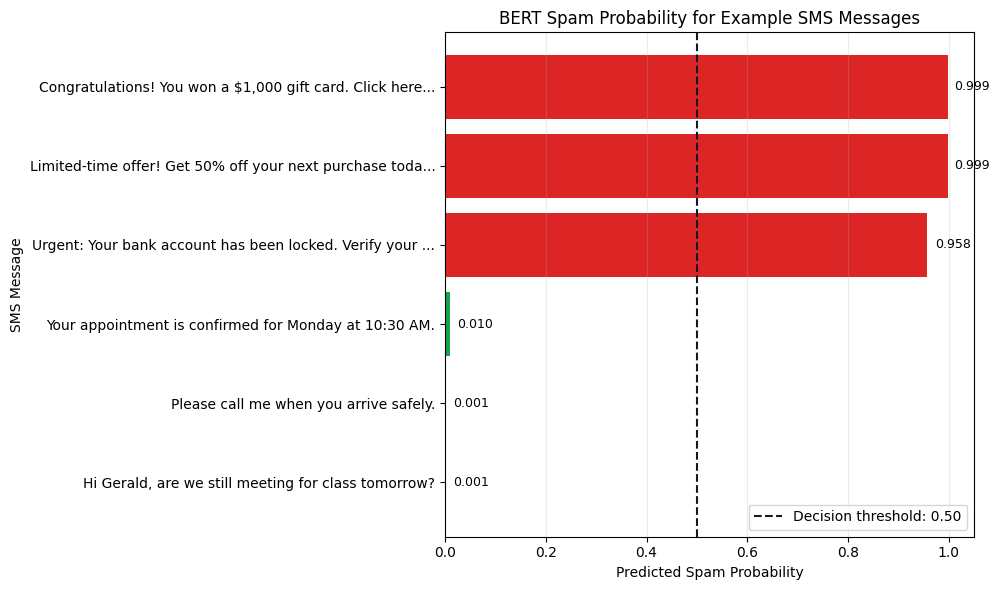

In [39]:
# Realistic demonstration messages.
demo_messages = [
    "Congratulations! You won a $1,000 gift card. Click here to claim it now.",
    "Urgent: Your bank account has been locked. Verify your details immediately.",
    "Limited-time offer! Get 50% off your next purchase today.",
    "Hi Gerald, are we still meeting for class tomorrow?",
    "Please call me when you arrive safely.",
    "Your appointment is confirmed for Monday at 10:30 AM."
]

# Score every demonstration message.
demo_results = pd.DataFrame(
    [predict_sms(message) for message in demo_messages]
)

# Improve column names for display.
demo_results = demo_results.rename(columns={
    "text": "SMS Message",
    "prediction": "Prediction",
    "confidence": "Confidence",
    "ham_probability": "Ham Probability",
    "spam_probability": "Spam Probability"
})

display(demo_results)

# Create a portfolio-ready probability chart.
chart_df = demo_results.sort_values(
    "Spam Probability",
    ascending=True
).copy()

colors = [
    "#DC2626" if prediction == "spam" else "#16A34A"
    for prediction in chart_df["Prediction"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    range(len(chart_df)),
    chart_df["Spam Probability"],
    color=colors
)

short_labels = [
    message[:55] + "..." if len(message) > 55 else message
    for message in chart_df["SMS Message"]
]

plt.yticks(
    range(len(chart_df)),
    short_labels
)

plt.axvline(
    best_threshold,
    color="#111827",
    linestyle="--",
    linewidth=1.5,
    label=f"Decision threshold: {best_threshold:.2f}"
)

plt.title("BERT Spam Probability for Example SMS Messages")
plt.xlabel("Predicted Spam Probability")
plt.ylabel("SMS Message")
plt.xlim(0, 1.05)
plt.grid(axis="x", alpha=0.25)
plt.legend(loc="lower right")

for bar, probability in zip(
    bars,
    chart_df["Spam Probability"]
):
    plt.text(
        min(probability + 0.015, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

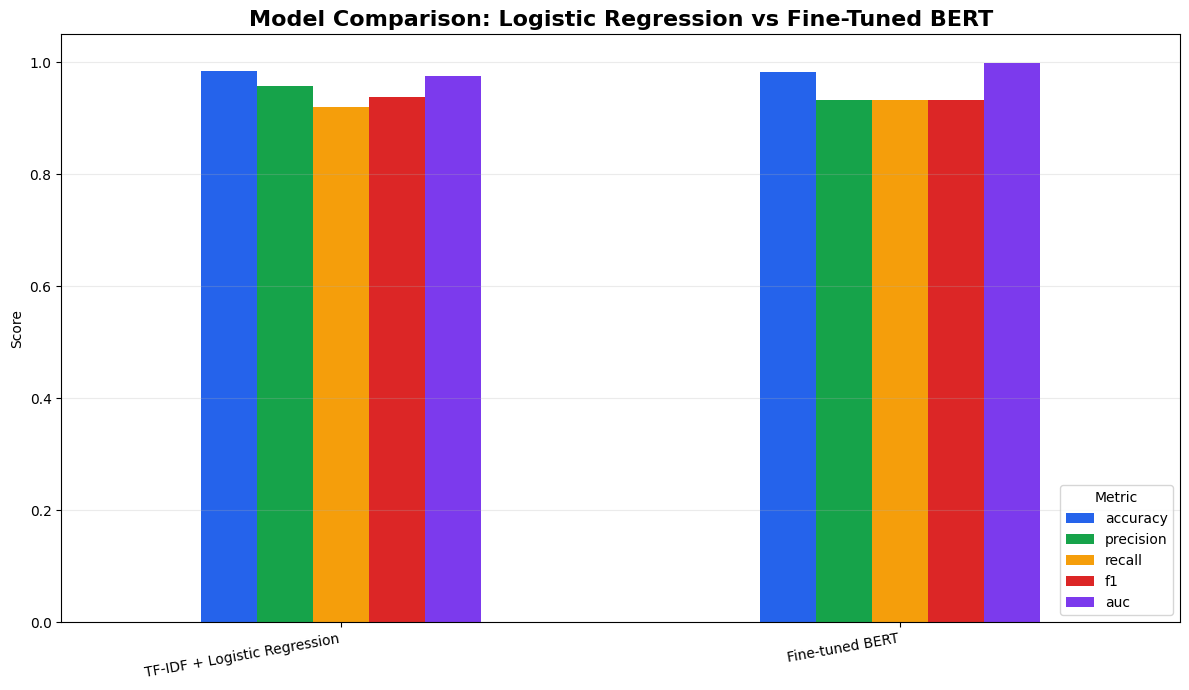

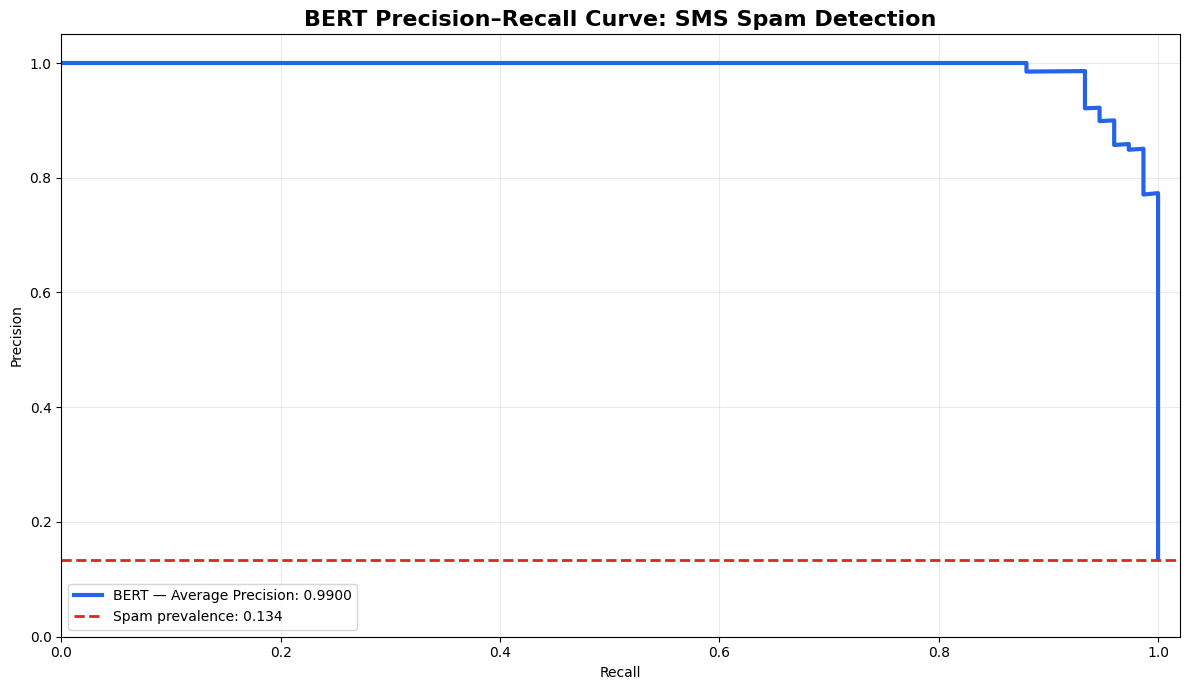

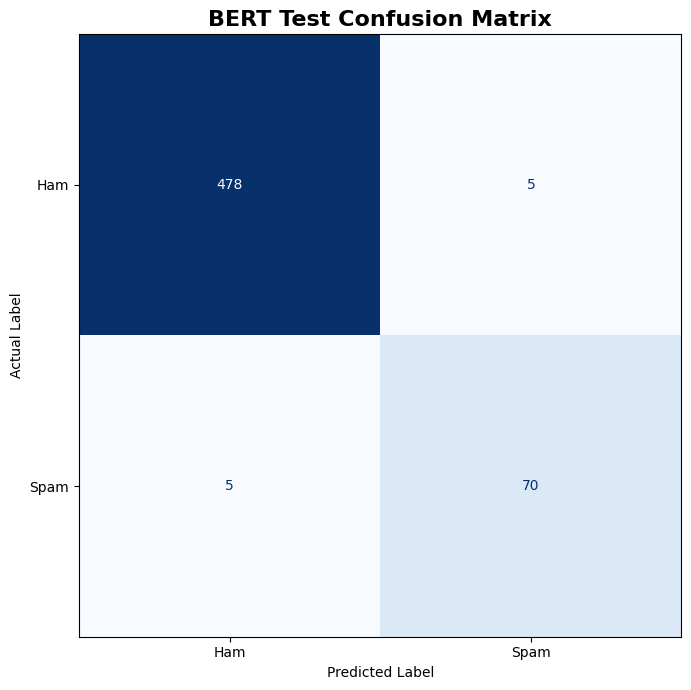

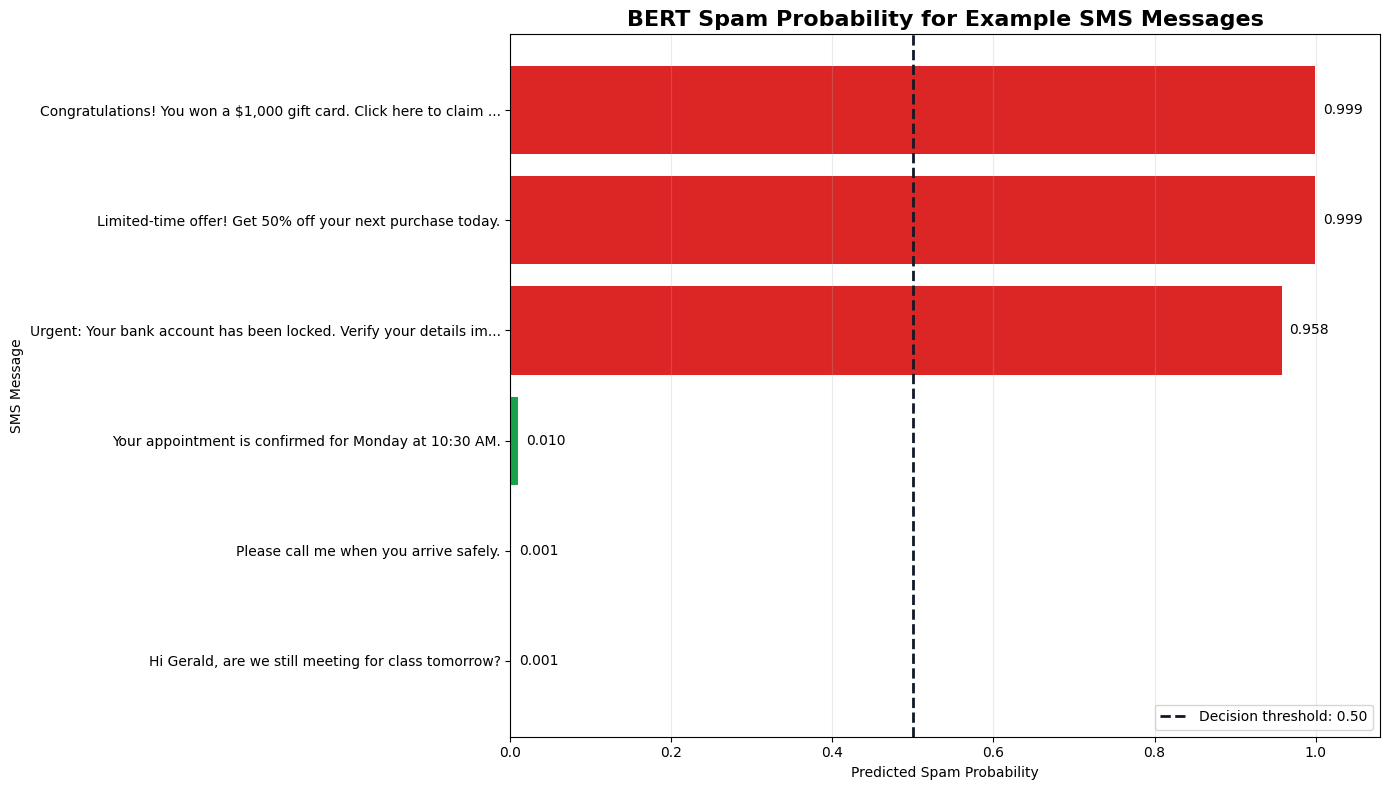

Four high-resolution portfolio images created successfully.


In [40]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create a folder for portfolio-ready images.
os.makedirs("portfolio_images", exist_ok=True)

# ============================================================
# 1. MODEL COMPARISON
# ============================================================

comparison_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc"
]

ax = results_df.set_index("model")[comparison_metrics].plot(
    kind="bar",
    figsize=(12, 7),
    color=["#2563EB", "#16A34A", "#F59E0B", "#DC2626", "#7C3AED"]
)

plt.title(
    "Model Comparison: Logistic Regression vs Fine-Tuned BERT",
    fontsize=16,
    fontweight="bold"
)
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.xticks(rotation=10, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()

plt.savefig(
    "portfolio_images/model-comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 2. PRECISION–RECALL CURVE
# ============================================================

plt.figure(figsize=(12, 7))

plt.plot(
    recall_values,
    precision_values,
    color="#2563EB",
    linewidth=3,
    label=f"BERT — Average Precision: {average_precision:.4f}"
)

plt.axhline(
    y=test_labels.mean(),
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=f"Spam prevalence: {test_labels.mean():.3f}"
)

plt.title(
    "BERT Precision–Recall Curve: SMS Spam Detection",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.02)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend(loc="lower left")
plt.tight_layout()

plt.savefig(
    "portfolio_images/precision-recall-curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 3. TEST CONFUSION MATRIX
# ============================================================

final_confusion_matrix = confusion_matrix(
    test_labels,
    optimized_test_predictions
)

figure, axis = plt.subplots(figsize=(8, 7))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=["Ham", "Spam"]
)

display_matrix.plot(
    ax=axis,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "BERT Test Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.savefig(
    "portfolio_images/error-analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 4. REALISTIC SMS PREDICTIONS
# ============================================================

chart_df = demo_results.sort_values(
    "Spam Probability",
    ascending=True
).copy()

colors = [
    "#DC2626" if prediction == "spam" else "#16A34A"
    for prediction in chart_df["Prediction"]
]

plt.figure(figsize=(14, 8))

bars = plt.barh(
    range(len(chart_df)),
    chart_df["Spam Probability"],
    color=colors
)

short_labels = [
    message[:65] + "..." if len(message) > 65 else message
    for message in chart_df["SMS Message"]
]

plt.yticks(
    range(len(chart_df)),
    short_labels
)

plt.axvline(
    best_threshold,
    color="#111827",
    linestyle="--",
    linewidth=2,
    label=f"Decision threshold: {best_threshold:.2f}"
)

plt.title(
    "BERT Spam Probability for Example SMS Messages",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Predicted Spam Probability")
plt.ylabel("SMS Message")
plt.xlim(0, 1.08)
plt.grid(axis="x", alpha=0.25)
plt.legend(loc="lower right")

for bar, probability in zip(
    bars,
    chart_df["Spam Probability"]
):
    plt.text(
        probability + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "portfolio_images/sms-prediction-demo.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Four high-resolution portfolio images created successfully.")